# Lab 051 · Why trees still win: re-derive the biases

[Lesson](../lessons/0051-why-trees-still-win.html) · [Reference](../reference/inductive-bias-interventions.html)

**Skill:** design and implement an intervention that distinguishes information content from learning behavior. **Scope: key parts** of Grinsztajn et al. §5; familiar numeric MLP and FT-T from L050 are displayed in full. XGBoost is a packaged baseline. You write four live functions, then the visible harness calls them in the actual experiment.

**Route:** recall → smoothing → rotation → noise → paired effects → complete training code → three-task run → EXIT → required larger run. PROVIDED is read/run; TODO is your implementation; CHECK gives diagnostics. Author-reference figures are measured snapshots, separate from your current outputs.

**Data contract:** Tier A, electricity 44120, MagicTelescope 44125 and bank-marketing 44126 from the authors' January 2023 OpenML suite 337. The learning lab uses 1800 rows per task, 60/20/20 stratified split seed 51, model seeds 0/1/2, fixed intervention seed 51. The suite is a later release than the 2022 paper v1 read here. Numeric binary classification only. Three tasks and fixed recipes do not reproduce the benchmark search curves: **INCOMPARABLE**.

Computation took about two CPU minutes in the author run; understanding and implementation take longer. Six portable inline PNGs require no execution. Local packaging checks do not certify the live Colab UI.

**Recall first:** why did three seeds in L050 not create three new datasets? Write your answer before proceeding.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

In [ ]:
# PROVIDED — environment; local repository root, labs/, or labs/solutions/ supported.
import os,sys,copy,hashlib,json,time,marshal,importlib.metadata,platform,types
from pathlib import Path
os.environ['OMP_NUM_THREADS']='1';os.environ['OPENBLAS_NUM_THREADS']='1'
os.environ.setdefault('MPLCONFIGDIR','/tmp/relational-matplotlib')
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from scipy.stats import special_ortho_group,t,rankdata,friedmanchisquare,studentized_range
from scipy.spatial.distance import cdist
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.covariance import MinCovDet
from sklearn.metrics import accuracy_score,roc_auc_score
from sklearn.datasets import fetch_openml
from xgboost import XGBClassifier
from threadpoolctl import threadpool_limits
from IPython.display import display
import matplotlib.pyplot as plt
thread_limit=threadpool_limits(limits=1);torch.set_num_threads(1)
for candidate in (Path.cwd(),Path.cwd()/'labs',Path.cwd().parent):
    if (candidate/'relkit').is_dir():
        LABS=candidate.resolve();sys.path.insert(0,str(LABS));os.chdir(LABS);break
else:raise RuntimeError('Run inside the course repository or use Colab bootstrap')
__file__=str(LABS/'relkit/bias_interventions.py')
print('Working directory:',LABS)

## 1. A bias is a preference, not a prohibition




An **inductive bias** is the preference a learning procedure uses to choose among explanations compatible with limited training data. A neural network may be able to represent a jagged boundary yet fail to learn it with a particular optimizer, sample size, regularization and training budget. **Expressivity** describes what a model can represent; **learning behavior** describes what training actually finds.




Read [Grinsztajn, Oyallon & Varoquaux (2022), §5](https://arxiv.org/html/2207.08815v1#S5) first. Its experiments connect neural/tree differences to irregular targets, irrelevant columns and feature orientation. They concern a defined tabular benchmark and specified training procedures, not an eternal ranking of model families. We reconstruct the interventions and test a new, explicitly local protocol.




| Hypothesis | Intervention | Required control |
| --- | --- | --- |
| A learner misses short-range label variation | Smooth training targets | Keep evaluation labels and selected features fixed |
| A learner depends on named coordinates | Apply one rotation to all splits | Keep rows, labels and information fixed |
| A learner is sensitive to irrelevant inputs | Append independent noise columns | Retain original columns and their values |




Each intervention changes something other than “the model name.” A clean protocol lets us identify a response to that intervention; it does not prove that only one internal mechanism caused the response. This is a synthesis of [L025](../lessons/0025-inductive-bias-smoothness.html), [L026](../lessons/0026-inductive-bias-rotation.html) and [L027](../lessons/0027-inductive-bias-uninformative-features.html), with stronger controls. No new architecture is introduced.

## 2. Smoothness: remove local label variation




**Smoothness** means nearby feature vectors tend to have similar outputs. In a one-dimensional signal, high-frequency variation changes rapidly over short distances. A threshold tree can place a sharp jump at one coordinate value. A neural learner can favor broader changes during fitting; the primary theoretical and empirical discussion is [Rahaman et al. (2019)](https://proceedings.mlr.press/v97/rahaman19a.html). This is a learning tendency, not a claim that ReLU networks cannot draw sharp boundaries.




Build a local average. Let *xᵢ* be training row i, *yᵢ* its binary label, *C* a covariance matrix fitted on training features, and *h* a nonnegative lengthscale. Covariance describes feature spread and joint variation; its inverse measures distance in units of that spread. The squared distance is `d²ᵢⱼ = (xᵢ − xⱼ)ᵀ C⁻¹ (xᵢ − xⱼ)`. Give nearby rows weight `wᵢⱼ = exp(−d²ᵢⱼ / (2h²))`, then calculate `pᵢ = Σⱼ wᵢⱼ yⱼ / Σⱼ wᵢⱼ`. The denominator makes the weights sum to one. Thus the result stays between zero and one.




The query row is also its own neighbor: its distance is zero and its weight is one. At h=0 we explicitly return the original targets. For positive h, larger neighborhoods mix labels. In the [pinned released classifier](https://github.com/LeoGrin/tabular-benchmark/blob/9d54cf53d9fd3159e367e70a00005f4fcbf2c79d/src/data_transforms.py), the next step is `new_y = (p > 0.5)`. A probability of exactly 0.5 becomes label 0. Our lab preserves this hard-label step.




**Predict:** for rows x=(0,1,2), labels y=(0,1,0), C=1, will the middle label survive at h=1?




At h=1 the weights into x=1 are approximately (0.607, 1, 0.607). Only the middle row contributes a positive label, so p=1/2.213≈0.452 and its label becomes 0. This is a computed synthetic example, not a reported dataset score.




**What stays fixed in the lab:** first select up to five features using training-only random-forest importance. Fit the covariance and transform on training rows. Compare unsmoothed and smoothed training labels on exactly those same columns; leave validation/test labels unchanged. Comparing full-feature raw data against five-feature smoothed data would confound smoothing with feature removal. The algorithm audit checks the released smoother on a nonsingular empirical-covariance example; the lab uses robust covariance with an explicit numerical eigenvalue floor. Neither check establishes full training parity.

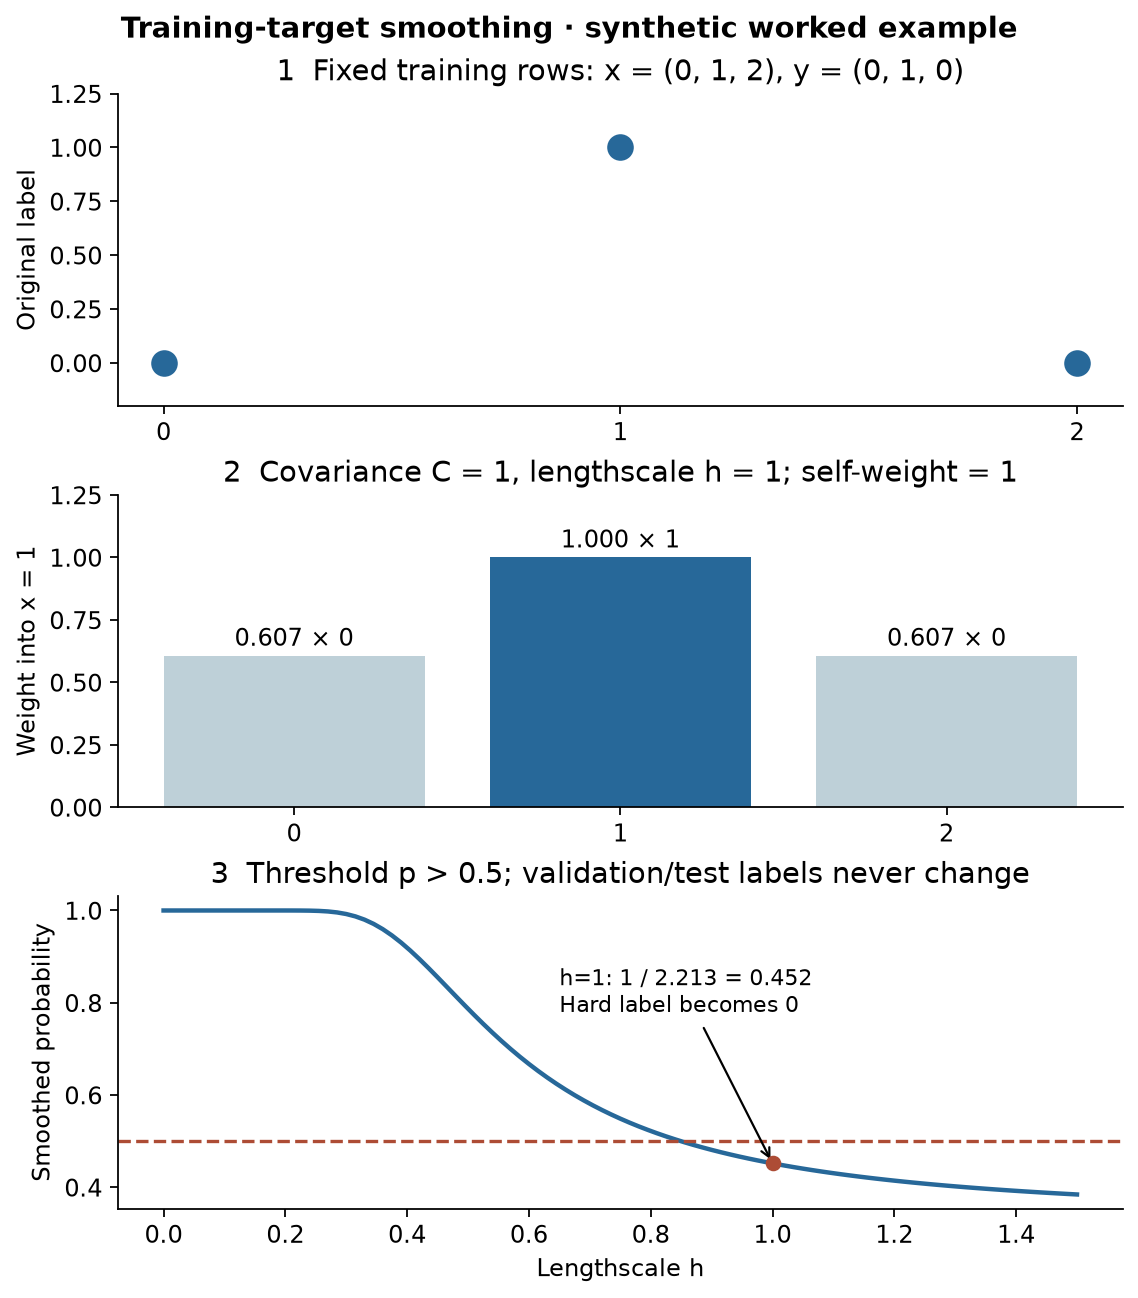

Synthetic smoothing: self-weight, neighbor weights, probability and hard threshold; test targets stay fixed.

### TODO 1 · Reconstruct the training-only smoother
Implement `smooth_targets(x,y,h,covariance)`. The covariance is already fitted on training rows. Chunking only limits memory; all training neighbors remain eligible. For h=0 copy the labels. For h>0 calculate the inverse-covariance distance, normalized weighted average and strict binary threshold. The three-row example is one CHECK, not the only input your function must handle.

**Predict before running:** multiplying all feature values by 3 and the covariance by 9 should do what to the smoothed output?

In [ ]:
# TODO 1 — Appendix A.4.1 mechanism and released classification threshold.
def smooth_targets(x,y,h,covariance):
    x,y=np.asarray(x,float),np.asarray(y,float)
    if h<0:raise ValueError('Lengthscale must be nonnegative')
    if h==0:return y.copy(),y.astype(int).copy()
    precision = ____
    probability=np.empty(len(y))
    for start in range(0,len(x),256):
        distances=cdist(x[start:start+256],x,'mahalanobis',VI=precision)**2
        weights = ____
        probability[start:start+256] = ____
    return probability, ____

In [ ]:
# CHECK 1 — arithmetic, units, self-weight and threshold convention.
x=np.arange(3.)[:,None];y=np.array([0,1,0]);cov=np.eye(1)
p,labels=smooth_targets(x,y,1.,cov)
assert np.isclose(p[1],1/(1+2*np.exp(-.5))), 'Normalize by all weights, including self.'
assert np.array_equal(labels,[0,0,0]), 'Threshold the probability, not the individual weights.'
assert np.array_equal(smooth_targets(x,y,0,cov)[1],y)
assert np.allclose(smooth_targets(3*x,y,1,9*cov)[0],p), 'Covariance must compensate the units.'
assert np.array_equal(smooth_targets(np.zeros((2,1)),np.array([0,1]),1,cov)[1],[0,0]), 'Exactly .5 must map to 0.'
print('CHECK 1 passed')

## 3. Orientation: preserve information, change the easy boundary




An **orthogonal matrix** R satisfies RᵀR=I, where I leaves a vector unchanged. Our random rotations also have determinant +1. With rows stored in a matrix X, transform them as X′=XR. Since R⁻¹=Rᵀ, the inverse X′Rᵀ recovers X. Pairwise squared distances remain unchanged: `‖(xᵢ−xⱼ)R‖² = ‖xᵢ−xⱼ‖²`. Rotation mixes coordinates without removing information.




An axis-aligned split asks about one coordinate, such as x₀>0.4. After a general rotation, the same boundary depends on a linear combination of coordinates. A finite tree may need several rectangular regions to approximate it. At a 90° rotation, however, the axes merely exchange roles with a sign change: the boundary is easy again. Rotation angle is not a universal difficulty scale.





For a neural first layer, use row notation `H = XWᵀ + b`, with X shaped [rows, features], W [hidden units, features], and b [hidden units]. Choose W′=WR. Then `(XR)(WR)ᵀ = XRRᵀWᵀ = XWᵀ`. All later layers receive exactly the same H. This proves **representation equivalence with transported weights**.




It does not prove that independent training runs find those weights. Exact rotation-equivariant gradient-descent trajectories need transported initialization, corresponding minibatches, and compatible regularization. Adam rescales gradients coordinate by coordinate. For a first-step gradient (1,0), ignoring its small numerical epsilon, its normalized direction is (1,0). Rotate that gradient 45° and normalizing each coordinate gives (1,−1), while rotating the original update gives (0.707,−0.707). The updates differ. Our AdamW lab therefore measures approximate sensitivity and never demands identical trained predictions.




**Protocol:** Gaussianize each feature using training-only quantiles, then apply one seeded R to all three splits. Do not fit another per-coordinate scaler after rotation: it changes the transformation you intended to test. A fresh matrix per split would instead create mismatched coordinate systems. Per-feature tokenization in FT-T treats named coordinates separately, so it does not inherit the dense-first-layer argument as a whole-model guarantee.

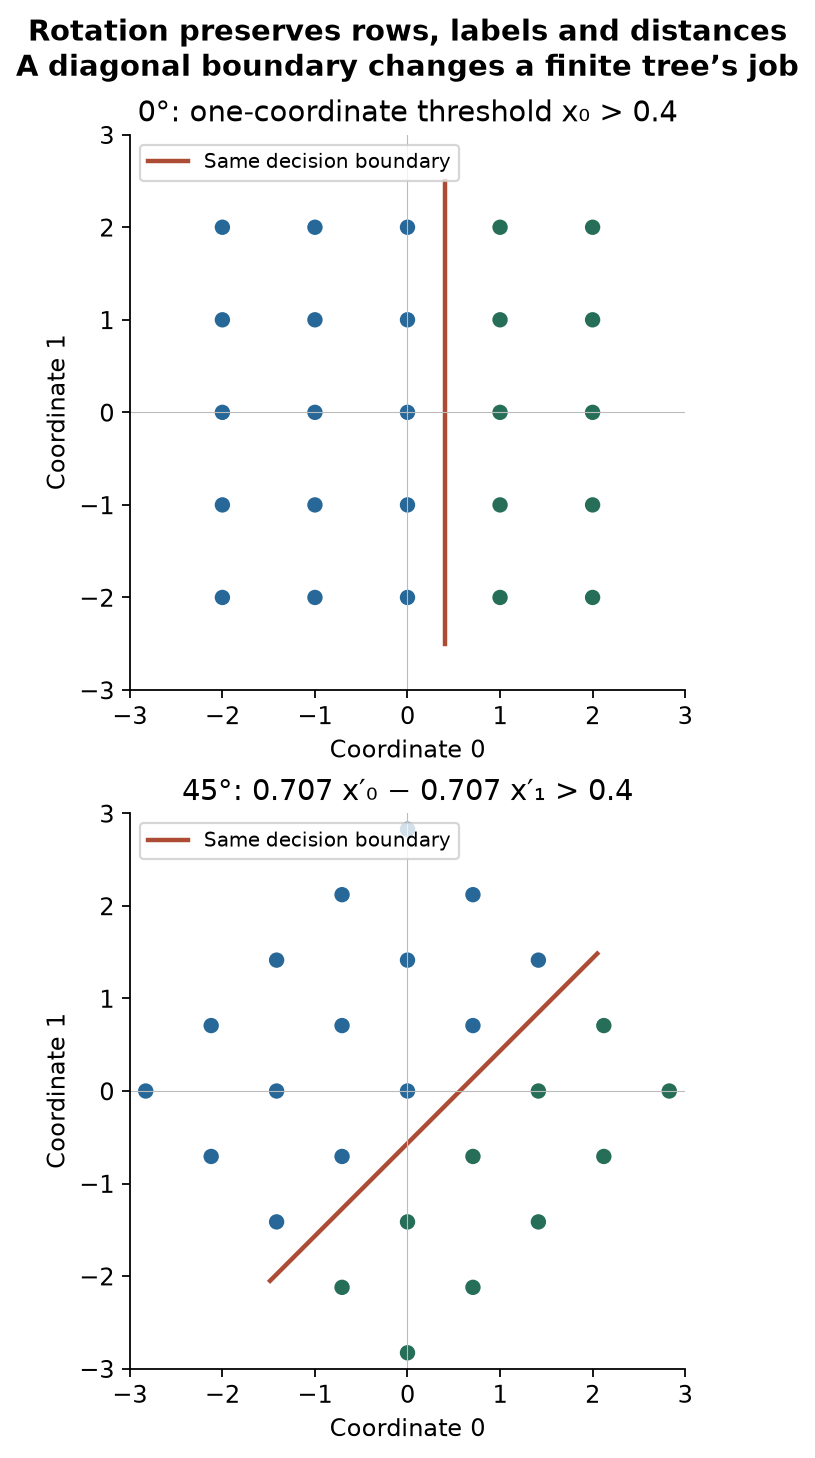

Synthetic 45-degree rotation: same labels and invertible inputs, but the one-coordinate threshold becomes diagonal.

### TODO 2 · Preserve a single coordinate system
Implement `rotate_splits(splits,rotation)`. The input is a list of arrays; return one transformed array for each. Reject a nonorthogonal matrix. Do not sample any new matrix inside this function.

**Prediction:** can the same dense first-layer activations be recovered exactly, even if a newly trained model later gets a different test score?

In [ ]:
# TODO 2 — apply one shared orthogonal transformation.
def rotate_splits(splits,rotation):
    r=np.asarray(rotation)
    if not ____:
        raise ValueError('Rotation must be orthogonal')
    return ____

In [ ]:
# CHECK 2 — inverse, distances and transported neural weights.
r=special_ortho_group.rvs(4,random_state=8)
rng=np.random.default_rng(1);x=rng.normal(size=(7,4));v=rng.normal(size=(3,4));w=rng.normal(size=(5,4))
z,zv=rotate_splits([x,v],r)
assert np.allclose(z@r.T,x) and np.allclose(zv@r.T,v), 'All splits need the same inverse.'
assert np.allclose(z@(w@r).T,x@w.T), 'Weight transport preserves first-layer activations.'
try:rotate_splits([x],2*np.eye(4))
except ValueError:pass
else:raise AssertionError('Scaling by 2 is not an orthogonal transform.')
print('CHECK 2 passed; this is weight transport, not Adam training parity.')

## 4. Irrelevant columns: separate “no signal” from “no harm”




A feature is **uninformative about the target** if observing it adds no predictive information in the population. Generate new values independently of rows and labels to construct that condition. Population independence does not force a finite sample correlation to be exactly zero. More columns create more chances to find a spurious pattern.




A tree searches thresholds and selects a split with large training improvement. For a binary node with positive fraction p, **Gini impurity** is 2p(1−p): zero for a pure node and 0.5 for a balanced one. Split gain is parent impurity minus the child impurities weighted by their row counts. The widget searches all between-row thresholds in 32 fixed synthetic training labels. Each new noise column adds another candidate maximum.





The maximum observed gain can only stay the same or increase as candidates are added. Trees therefore can overfit irrelevant features; their robustness is empirical and depends on sample size, depth and regularization. An MLP with H first-layer units gains H parameters per extra input. That is an accounting fact, not a theorem that its test score must fall or that it cannot learn zero weights.




**Protocol:** append 2d independent standard-Gaussian columns to a d-column input, making 3d columns. Use different draws for train, validation and test while keeping the same column interpretation. The figure-caption distribution and the released code are not identical: the code matches sampled training-column means and interquartile scales. Our experiment explicitly follows the standard-normal description and records the difference. Noise features are not the same as redundant features: a duplicate of a useful column can still predict the target.




The link to orientation is instructive: if useful information resides in a small set of named columns, a method that exploits that basis can search for those columns directly. After dense mixing, the same signal may be spread over many coordinates. This motivates a testable hypothesis, not a universal rule for all tabular learners. See [Ng (2004)](https://dl.acm.org/doi/10.1145/1015330.1015435) for the conditional worst-case sample-complexity result.

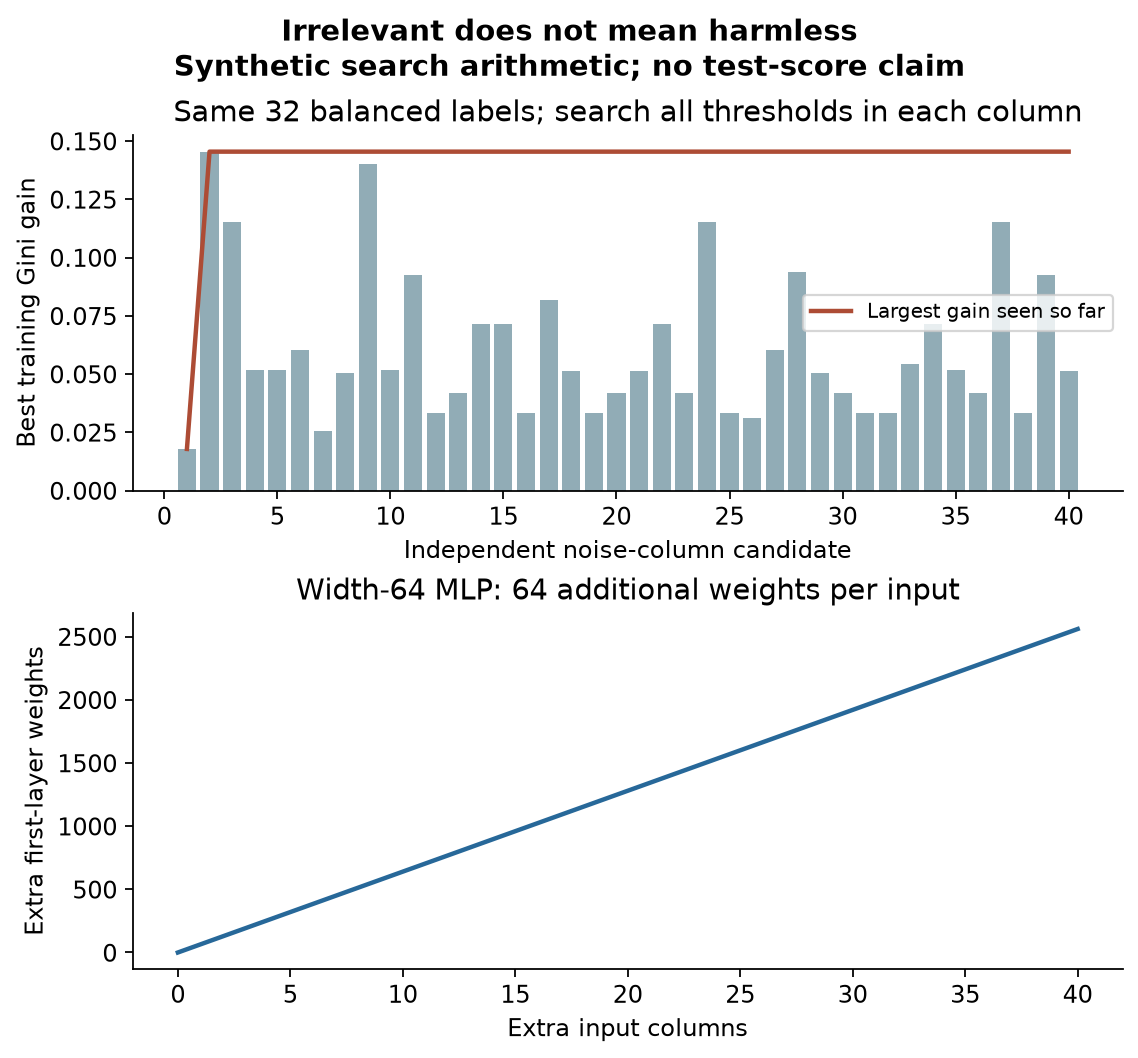

Synthetic finite-sample noise search and MLP parameter accounting. No test-score claim follows from either plot alone.

### TODO 3 · Add independent noise while preserving the original block
Implement `add_noise_features(splits,count,seed)`. Create one generator before processing the splits, append `count` N(0,1) columns to each array, and return the list. Labels are intentionally absent from the signature. Do not restart the generator inside the split loop.

**Written check:** why should you not assert exact zero sample correlation between generated columns and labels?

In [ ]:
# TODO 3 — independent draws, reproducible intervention.
def add_noise_features(splits,count,seed):
    rng = ____
    return ____

In [ ]:
# CHECK 3 — original values, distinct splits, repeatability and zero-column identity.
x=np.arange(12).reshape(4,3);v=x+20
a,b=add_noise_features([x,v],5,51)
assert a.shape==(4,8) and np.array_equal(a[:,:3],x)
assert np.array_equal(b[:,:3],v) and not np.array_equal(a[:,3:],b[:,3:]), 'Do not reuse a noise block across splits.'
assert np.array_equal(a,add_noise_features([x,v],5,51)[0])
assert np.array_equal(add_noise_features([x],0,51)[0],x)
print('CHECK 3 passed')

## 5. The local experiment you will reconstruct




**Implementation scope: key parts.** You implement smoothing, consistent rotation, independent noise insertion and paired effects. The notebook displays the complete numeric MLP and FT-T reused from L050, together with the train loop. XGBoost is an existing packaged baseline. This lesson tests intervention mechanisms; it does not introduce or reimplement a new booster.




**Data:** the authors’ January 2023 numeric-classification release, OpenML suite 337: electricity (44120), MagicTelescope (44125) and bank-marketing (44126). Each local task takes 1,800 rows selected without inspecting labels, then stratifies them into 60/20/20 training/validation/test partitions with split seed 51. Model seeds are 0, 1 and 2. The source paper read here is v1 from 2022, so this later dataset release is a named fidelity difference.




**Preprocessing:** fit QuantileTransformer only on training rows. It maps each value’s training percentile to the corresponding standard-normal quantile, making marginal feature distributions approximately Gaussian. Smoothing uses a training-only top-five ranking, MinCovDet robust covariance, h=0.5 and hard labels. MinCovDet estimates covariance from a central subset to reduce outlier influence. An eigenvalue measures spread along a covariance direction; flooring very small eigenvalues makes its inverse numerically usable. The eigenvalue floor prevents numerical singularity; the resulting matrix is saved, and covariance warnings are recorded in the executed solution. Transformation seed 51 is fixed across model seeds. There is no claim about uncertainty across fresh rotations or noise realizations.




**Training:** two-hidden-layer width-64 MLP; numeric d=32, two-block, four-head FT-T with ReGLU; depth-4 XGBoost. Neural caps are 20 epochs, tree cap 120 rounds, with patience 12 on validation loss. Neural batch size is 256, AdamW learning rate 0.001 and weight decay 10⁻⁵. Tree learning rate is 0.05, row subsampling 0.8. Fixed recipes isolate sensitivity under these procedures; they do not allocate equal wall-clock budgets or reproduce the paper’s hyperparameter searches. We restore the best validation checkpoint before test evaluation.




**Metric:** accuracy, the fraction of correct binary predictions at threshold 0.5; AUROC, the probability that a randomly chosen positive is ranked above a randomly chosen negative (with half credit for ties), is also saved. An effect is changed-condition accuracy minus its matched baseline. Rotation and noise use “original”; smoothing uses “top5.” A negative effect means the intervention hurt that arm.




Each mean ± sample standard deviation describes three training seeds on one shared split. Paired 95% t intervals subtract matched seeds before estimating variability; they are conditional seed intervals, not confidence about future datasets. Within a dataset, rank 1 is best and ties share an average rank. The Friedman test asks whether model ranks differ systematically across datasets; the Nemenyi critical difference (CD) is the rank separation needed for its pairwise comparison. Dataset-level mean ranks, a Friedman test and a Nemenyi critical difference are descriptive safeguards with only N=3 tasks. Five intervention conditions do not create fifteen independent datasets. The statistical rationale is [Demšar (2006)](https://www.jmlr.org/papers/v7/demsar06a.html).

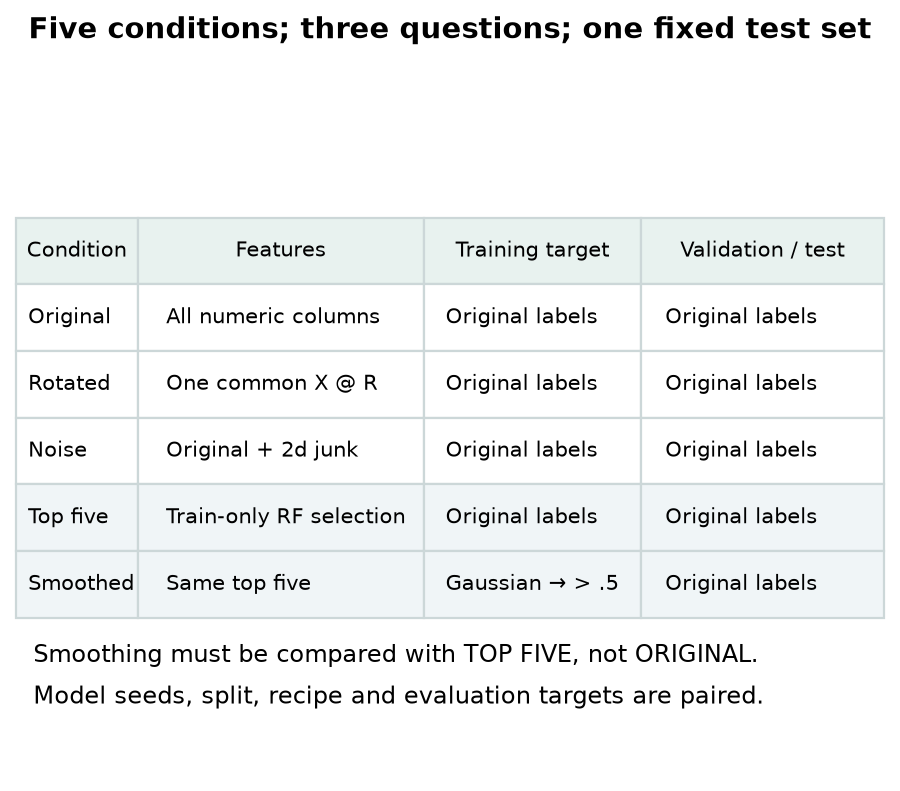

Every condition preserves evaluation targets. Compare smoothing against top-five raw targets, not full-feature original.

### TODO 4 · Pair the effect before estimating uncertainty
Implement `paired_effect(changed,baseline)`. Return mean, sample SD (`ddof=1`) and 95% t interval for seed-wise differences. With one seed return `None` for SD and interval. Positive means the intervention improved accuracy. These intervals condition on one split and one fixed intervention realization.

**Predict:** if all three paired differences are exactly +0.01, should the interval be wide just because the underlying model scores differ?

In [ ]:
# TODO 4 — differences first; S model seeds means S−1 degrees of freedom.
def paired_effect(changed,baseline):
    delta = ____
    mean=float(delta.mean())
    if len(delta)<2:return dict(mean=mean,sd=None,ci95=None)
    sd = ____
    half = ____
    return dict(mean=mean,sd=sd,ci95=[mean-half,mean+half])

In [ ]:
# CHECK 4 — pairing and uncertainty units.
e=paired_effect([.81,.86,.91],[.80,.85,.90])
assert np.isclose(e['mean'],.01) and e['sd']<1e-12
e=paired_effect([.8,.85,.9],[.8,.8,.8]);assert np.isclose(e['sd'],.05)
assert np.isclose(e['ci95'][1]-e['mean'],t.ppf(.975,2)*.05/np.sqrt(3))
assert paired_effect([.8],[.7])['ci95'] is None
print('CHECK 4 passed')

## PROVIDED · Familiar models, visible end to end
These are the L050 numeric models, not new architectures. An MLP maps [B,d] through two width-64 linear/ReLU/dropout layers to one logit. FT-T embeds each numeric feature as `x_j w_j + b_j`, prepends CLS, applies two attention/ReGLU residual blocks, normalizes CLS and reads one logit. The first block skips attention LayerNorm. B is rows, d is input columns; FT-T token width is 32. Sigmoid turns a logit into a probability. Read the implementations and locate where input dimensionality enters each one.

In [ ]:
# PROVIDED — MLP and FT-T activation from L050
def reglu(x):
    """Appendix E: split the 2h coordinates, then a * max(b, 0)."""
    a, b = x.chunk(2, dim=-1)
    return a * F.relu(b)


class CheckpointMLP(nn.Module):
    """§3.1 baseline: two linear/ReLU/dropout layers and one binary head."""
    def __init__(self, features, d=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(features,d), nn.ReLU(), nn.Dropout(.1),
                                 nn.Linear(d,d), nn.ReLU(), nn.Dropout(.1), nn.Linear(d,1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

In [ ]:
# PROVIDED — attention, ReGLU and residual connections
class CheckpointAttention(nn.Module):
    """§3.3: independent Q/K/V maps, scaled scores, weighted values, projection."""
    def __init__(self, d, heads, dropout):
        super().__init__()
        self.heads = heads
        self.q, self.k, self.v, self.out = [nn.Linear(d, d) for _ in range(4)]
        self.drop = nn.Dropout(dropout)
        for layer in (self.q, self.k, self.v, self.out):
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        b, c, d = x.shape
        def split(layer):
            return layer(x).reshape(b, c, self.heads, d//self.heads).transpose(1, 2)
        q, k, v = split(self.q), split(self.k), split(self.v)
        weights = torch.softmax(q @ k.transpose(-1, -2) / (d//self.heads)**.5, -1)
        mixed = (self.drop(weights) @ v).transpose(1, 2).reshape(b, c, d)
        return self.out(mixed)


class CheckpointBlock(nn.Module):
    """First attention has no LayerNorm; FFN always has pre-normalization."""
    def __init__(self, d, heads, first, attention_dropout, ffn_dropout):
        super().__init__()
        self.norm1 = nn.Identity() if first else nn.LayerNorm(d)
        self.attention = CheckpointAttention(d, heads, attention_dropout)
        self.norm2 = nn.LayerNorm(d)
        hidden = int(d * 4/3)
        self.linear1, self.linear2 = nn.Linear(d, 2*hidden), nn.Linear(hidden, d)
        self.drop = nn.Dropout(ffn_dropout)

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        return x + self.linear2(self.drop(reglu(self.linear1(self.norm2(x)))))

In [ ]:
# PROVIDED — complete numeric FT-T prediction path
class CheckpointFT(nn.Module):
    """Full numeric prediction path; residual dropout fixed at zero."""
    def __init__(self, features, d=32, layers=2, heads=4, attention_dropout=.1, ffn_dropout=.1):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(features, d))
        self.bias = nn.Parameter(torch.empty(features, d))
        self.cls = nn.Parameter(torch.empty(d))
        for p in (self.weight, self.bias, self.cls):
            nn.init.uniform_(p, -d**-.5, d**-.5)
        self.blocks = nn.ModuleList([CheckpointBlock(d, heads, i == 0, attention_dropout, ffn_dropout) for i in range(layers)])
        self.norm, self.head = nn.LayerNorm(d), nn.Linear(d, 1)

    def forward(self, x):
        tokens = x.unsqueeze(-1) * self.weight + self.bias
        tokens = torch.cat([self.cls.expand(len(x), 1, -1), tokens], 1)
        for block in self.blocks:
            tokens = block(tokens)
        return self.head(F.relu(self.norm(tokens[:, 0]))).squeeze(-1)

In [ ]:
# PROVIDED — fixed recipe, validation loss, restored checkpoint and test inference
def fit_arm(arm,x,y,yvalid,seed,epochs,trees,device='cpu'):
    """Visible local protocol: fixed HPs, validation early stopping, no test selection.

    All conditions use identical caps. These are sensitivity measurements at fixed
    training recipes, not equal-compute optimized model-family rankings.
    """
    torch.manual_seed(seed)
    if arm=='XGBoost':
        model=XGBClassifier(n_estimators=trees,max_depth=4,learning_rate=.05,subsample=.8,
                            colsample_bytree=1.,n_jobs=1,tree_method='hist',random_state=seed,
                            eval_metric='logloss',early_stopping_rounds=12)
        model.fit(x[0],y,eval_set=[(x[1],yvalid)],verbose=False)
        return model.predict_proba(x[2])[:,1],dict(best_epoch=int(model.best_iteration)+1,best_validation_loss=float(model.best_score))
    model=(CheckpointMLP(x[0].shape[1],d=64) if arm=='MLP' else
           CheckpointFT(x[0].shape[1],d=32,layers=2,heads=4)).to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=.001,weight_decay=1e-5)
    xx=torch.as_tensor(x[0],dtype=torch.float32,device=device)
    yy=torch.as_tensor(y,dtype=torch.float32,device=device)
    xv=torch.as_tensor(x[1],dtype=torch.float32,device=device)
    yv=torch.as_tensor(yvalid,dtype=torch.float32,device=device)
    generator=torch.Generator().manual_seed(seed)
    best=float('inf');best_epoch=0;state=None
    for epoch in range(epochs):
        model.train()
        for idx in torch.randperm(len(xx),generator=generator).split(256):
            optimizer.zero_grad();loss=F.binary_cross_entropy_with_logits(model(xx[idx.to(device)]),yy[idx.to(device)])
            loss.backward();optimizer.step()
        model.eval()
        with torch.no_grad():value=float(F.binary_cross_entropy_with_logits(model(xv),yv))
        if value<best:
            best=value;best_epoch=epoch+1;state=copy.deepcopy(model.state_dict())
        elif epoch+1-best_epoch>=12:break
    model.load_state_dict(state);model.eval()
    with torch.no_grad():
        p=torch.cat([model(torch.as_tensor(a,dtype=torch.float32,device=device)).sigmoid().cpu() for a in np.array_split(x[2],max(1,int(np.ceil(len(x[2])/512))))]).numpy()
    return p,dict(best_epoch=best_epoch,best_validation_loss=best)

In [ ]:
# PROVIDED — declared datasets, presets, conditions and model arms
DATASETS={'electricity':44120,'MagicTelescope':44125,'bank-marketing':44126}
PRESETS={'smoke':dict(max_rows=500,epochs=3,trees=25,seeds=[0]),
         'lab':dict(max_rows=1800,epochs=20,trees=120,seeds=[0,1,2]),
         'closer':dict(max_rows=6000,epochs=50,trees=400,seeds=[0,1,2]),
         'paper':dict(max_rows=20000,epochs=100,trees=1000,seeds=[0,1,2,3,4])}
CONDITIONS=['original','rotated','noise','top5','smoothed']
MODELS=['MLP','FT-T','XGBoost']

In [ ]:
# PROVIDED — load exact OpenML IDs, retain file hash and target mapping
def load_task(name,cache):
    path=Path(cache)/f'{name}.parquet'
    if not path.exists():
        data=fetch_openml(data_id=DATASETS[name],as_frame=True,parser='auto',data_home=str(Path(cache)/'openml'))
        frame=data.data.copy();frame['__target__']=data.target
        path.parent.mkdir(parents=True,exist_ok=True);frame.to_parquet(path,index=False)
    frame=pd.read_parquet(path);raw=frame.pop('__target__').astype(str)
    classes=sorted(raw.unique())
    if len(classes)!=2:raise ValueError('This lesson requires binary targets')
    x=frame.to_numpy(dtype=float);y=(raw==classes[1]).to_numpy(dtype=int)
    if not np.isfinite(x).all():raise ValueError('Released numeric data expected to be finite')
    return x,y,dict(openml_id=DATASETS[name],sha256=hashlib.sha256(path.read_bytes()).hexdigest(),classes=classes,full_rows=len(y))

In [ ]:
# PROVIDED — read training-only feature ranking, covariance, and calls to your live interventions
def prepare_task(name,cache,max_rows,split_seed=51):
    x,y,metadata=load_task(name,cache)
    selected=np.arange(len(y))
    if len(y)>max_rows:
        selected=np.sort(np.random.default_rng(51).choice(len(y),max_rows,replace=False))
    x,y=x[selected],y[selected]
    tr,rest=train_test_split(np.arange(len(y)),test_size=.4,stratify=y,random_state=split_seed)
    va,te=train_test_split(rest,test_size=.5,stratify=y[rest],random_state=split_seed)
    transformer=QuantileTransformer(n_quantiles=min(1000,len(tr)),output_distribution='normal',random_state=51,subsample=None)
    original=[transformer.fit_transform(x[tr]),transformer.transform(x[va]),transformer.transform(x[te])]
    labels=[y[tr],y[va],y[te]]
    # Labels in va/te never enter feature selection, covariance or smoothing.
    ranking=RandomForestClassifier(n_estimators=100,random_state=51,n_jobs=1).fit(original[0],labels[0]).feature_importances_
    keep=np.argsort(ranking,kind='stable')[-min(5,x.shape[1]):]
    top=[a[:,keep] for a in original]
    cov=MinCovDet(random_state=51).fit(top[0]).covariance_
    vals,vecs=np.linalg.eigh(cov);floor=max(float(vals.max())*1e-8,1e-10)
    cov=(vecs*np.maximum(vals,floor))@vecs.T
    probability,smoothed=smooth_targets(top[0],labels[0],.5,cov)
    rotation=special_ortho_group.rvs(x.shape[1],random_state=51)
    states={'original':(original,labels[0]),'rotated':(rotate_splits(original,rotation),labels[0]),
            'noise':(add_noise_features(original,2*x.shape[1],51),labels[0]),
            'top5':(top,labels[0]),'smoothed':(top,smoothed)}
    metadata.update(selected_rows=selected.tolist(),split_rows=[selected[i].tolist() for i in [tr,va,te]],
                    dimensions=x.shape[1],top5=keep.tolist(),covariance=cov.tolist(),eigenvalue_floor=floor,
                    rotation=rotation.tolist(),smoothed_probability=probability.tolist(),
                    changed_training_labels=int(np.sum(smoothed!=labels[0])),test_y=labels[2].tolist(),
                    smoothing_h=.5,split_seed=split_seed,transform_seed=51)
    return states,labels,metadata

In [ ]:
# PROVIDED — full experiment and dataset-level rank statistics
def rank_summary(datasets,condition):
    scores=np.array([[np.mean([r['accuracy'] for r in row['runs'][condition][m]]) for m in MODELS] for row in datasets.values()])
    ranks=np.array([rankdata(-r) for r in scores]);n,k=scores.shape
    p=float(friedmanchisquare(*scores.T).pvalue) if n>1 else None
    cd=float(studentized_range.ppf(.95,k,np.inf)/2**.5*(k*(k+1)/(6*n))**.5)
    return dict(mean_ranks=dict(zip(MODELS,ranks.mean(0).tolist())),friedman_p=p,cd=cd,N=n)


def run_experiment(preset='lab',names=None,cache=None,device='cpu',progress=True):
    cfg=PRESETS[preset].copy();names=list(DATASETS) if names is None else list(names)
    cache=Path(cache or Path(__file__).resolve().parents[1]/'data/cache/l051')
    torch.set_num_threads(1);start=time.perf_counter()
    result=dict(preset=preset,config=cfg,protocol='L051 fixed-recipe sensitivity v1',verdict='INCOMPARABLE',
                versions={p:importlib.metadata.version(p) for p in ['numpy','scipy','scikit-learn','torch','xgboost','pandas']},
                device=device,datasets={})
    for name in names:
        states,labels,row=prepare_task(name,cache,cfg['max_rows']);row['runs']={}
        for condition,(xs,train_y) in states.items():
            row['runs'][condition]={}
            for arm in MODELS:
                runs=[]
                for seed in cfg['seeds']:
                    p,log=fit_arm(arm,xs,train_y,labels[1],seed,cfg['epochs'],cfg['trees'],device)
                    runs.append(dict(seed=seed,accuracy=float(accuracy_score(labels[2],p>=.5)),
                                     auc=float(roc_auc_score(labels[2],p)),probability=p.tolist(),**log))
                row['runs'][condition][arm]=runs
            if progress:print(name,condition,{m:round(np.mean([r['accuracy'] for r in row['runs'][condition][m]]),4) for m in MODELS},flush=True)
        row['effects']={c:{m:paired_effect([r['accuracy'] for r in row['runs'][c][m]],
                            [r['accuracy'] for r in row['runs']['top5' if c=='smoothed' else 'original'][m]])
                            for m in MODELS} for c in ['rotated','noise','smoothed']}
        result['datasets'][name]=row
    result['statistics']={c:rank_summary(result['datasets'],c) for c in CONDITIONS}
    result['elapsed_s']=time.perf_counter()-start
    return result

In [ ]:
# CHECK — prove your functions are on the real preparation path.
originals={n:globals()[n] for n in ['smooth_targets','rotate_splits','add_noise_features']};calls={n:0 for n in originals}
def counted(name,fn):
    def wrapped(*args,**kwargs):
        calls[name]+=1;return fn(*args,**kwargs)
    return wrapped
try:
    for name,fn in originals.items():globals()[name]=counted(name,fn)
    states,labels,metadata=prepare_task('electricity',LABS/'data/cache/l051',500)
finally:
    globals().update(originals)
assert all(calls[n]==1 for n in calls), 'The preparation path bypassed a student function.'
assert np.array_equal(states['smoothed'][0][0],states['top5'][0][0]), 'Smoothing changed the feature set.'
assert np.array_equal(states['smoothed'][0][2],states['top5'][0][2])
assert np.array_equal(labels[2],metadata['test_y'])
print('CHECK: live intervention calls:',calls)

## Predict before measuring
Write one expected sign for each model under each intervention, plus one reason the sign might differ on a small task. Then run the complete comparison. The author-reference snapshot comes afterward; do not edit seeds or conditions until your result matches it.

In [ ]:
# PROVIDED — trains visible models and uses your current student functions.
result=run_experiment('lab',cache=LABS/'data/cache/l051')
records=[]
for dataset,row in result['datasets'].items():
    for condition,runs in row['runs'].items():
        for model,rr in runs.items():
            a=np.array([r['accuracy'] for r in rr])
            records.append(dict(dataset=dataset,condition=condition,model=model,accuracy=a.mean(),seed_sd=a.std(ddof=1)))
scores=pd.DataFrame(records);display(scores.round(4))
display(pd.DataFrame(result['statistics']).T)
print('INCOMPARABLE to paper search curves; seconds:',round(result['elapsed_s']))

In [ ]:
# PROVIDED — YOUR runtime effects with paired seed points and conditional intervals.
fig,axes=plt.subplots(3,1,figsize=(8,10),layout='constrained')
for ax,condition in zip(axes,['rotated','noise','smoothed']):
    for i,(dataset,row) in enumerate(result['datasets'].items()):
        for j,model in enumerate(MODELS):
            e=row['effects'][condition][model];pos=i+(j-1)*.2
            base='top5' if condition=='smoothed' else 'original'
            d=np.array([a['accuracy']-b['accuracy'] for a,b in zip(row['runs'][condition][model],row['runs'][base][model])])*100
            color=['#276e58','#276899','#ad4c35'][j]
            ax.scatter(d,[pos]*len(d),color=color,s=16)
            ax.errorbar(e['mean']*100,pos,xerr=[[100*(e['mean']-e['ci95'][0])],[100*(e['ci95'][1]-e['mean'])]],fmt='D',color=color,capsize=3,label=model if i==0 else None)
    ax.axvline(0,color='gray',ls='--');ax.set(yticks=range(3),yticklabels=list(result['datasets']),xlabel='Change in accuracy (percentage points)',title=condition);ax.legend(ncol=3)
plt.show()

## Author-reference evidence · a separate recorded run
The following is the author's measured snapshot, not your kernel state. Compare protocol and arithmetic before interpreting numerical differences. Do not treat three paired seed intervals as uncertainty about future datasets.

## 6. Read the evidence without repairing the story




**Author measurement:** 119 seconds for the local CPU experiment. Accuracy ± sample SD across three seeds; the table contains local evidence, not paper targets.





| Dataset | Condition | MLP | FT-T | XGBoost |
| --- | --- | --- | --- | --- |
| electricity | original | 0.7389 ± 0.0073 | 0.7685 ± 0.0098 | 0.7889 ± 0.0073 |
| electricity | rotated | 0.7500 ± 0.0028 | 0.7398 ± 0.0098 | 0.7611 ± 0.0028 |
| electricity | noise | 0.7259 ± 0.0137 | 0.7713 ± 0.0131 | 0.8019 ± 0.0140 |
| electricity | top5 | 0.7463 ± 0.0016 | 0.7713 ± 0.0064 | 0.7815 ± 0.0042 |
| electricity | smoothed | 0.7398 ± 0.0105 | 0.7509 ± 0.0264 | 0.7778 ± 0.0083 |
| MagicTelescope | original | 0.8019 ± 0.0064 | 0.8093 ± 0.0064 | 0.8157 ± 0.0058 |
| MagicTelescope | rotated | 0.8065 ± 0.0143 | 0.7889 ± 0.0121 | 0.7657 ± 0.0064 |
| MagicTelescope | noise | 0.7296 ± 0.0032 | 0.7769 ± 0.0105 | 0.7824 ± 0.0080 |
| MagicTelescope | top5 | 0.7907 ± 0.0032 | 0.7907 ± 0.0058 | 0.8111 ± 0.0000 |
| MagicTelescope | smoothed | 0.7843 ± 0.0105 | 0.7870 ± 0.0105 | 0.7926 ± 0.0042 |
| bank-marketing | original | 0.7935 ± 0.0098 | 0.7926 ± 0.0112 | 0.7889 ± 0.0073 |
| bank-marketing | rotated | 0.7991 ± 0.0116 | 0.7815 ± 0.0105 | 0.7741 ± 0.0032 |
| bank-marketing | noise | 0.7694 ± 0.0127 | 0.7731 ± 0.0098 | 0.7778 ± 0.0083 |
| bank-marketing | top5 | 0.7843 ± 0.0070 | 0.7880 ± 0.0179 | 0.7870 ± 0.0042 |
| bank-marketing | smoothed | 0.7796 ± 0.0143 | 0.7889 ± 0.0000 | 0.7852 ± 0.0042 |





Rotation effects averaged equally over the three tasks: MLP +0.71 percentage points, FT-T -2.01 percentage points, XGBoost -3.09 percentage points. These are task averages, not nine independent task observations.



For added noise, electricity XGBoost rises while its other two task scores fall. Smoothing changes electricity: 125/1080, MagicTelescope: 74/1080, bank-marketing: 138/1080 training labels. FT-T improves slightly on smoothed bank marketing while the other smoothing effects are negative. These exceptions belong in the report.



Original-condition Friedman p=0.717. The noise condition has unadjusted asymptotic p≈0.0498, but it is one of five exploratory tests on only three tasks; it does not survive a Bonferroni threshold of 0.01. Do not use this isolated threshold crossing as the conclusion.





The smoothing comparison estimates the effect of changing training labels, not the benefit of deploying a smoothed target. A flat response can mean robustness, weak smoothing, early stopping or low power. Inspect the number of training labels actually changed before choosing an explanation. A rotation penalty can expose coordinate sensitivity while leaving the model’s absolute accuracy competitive.




For the mission, this raises the baseline standard: before interpreting an RDL gain, ask whether its representation changed feature orientation, removed irrelevant inputs, exposed temporal information, or preserved detail that flattening discarded. This tabular experiment itself supplies no direct evidence that a relational model wins.

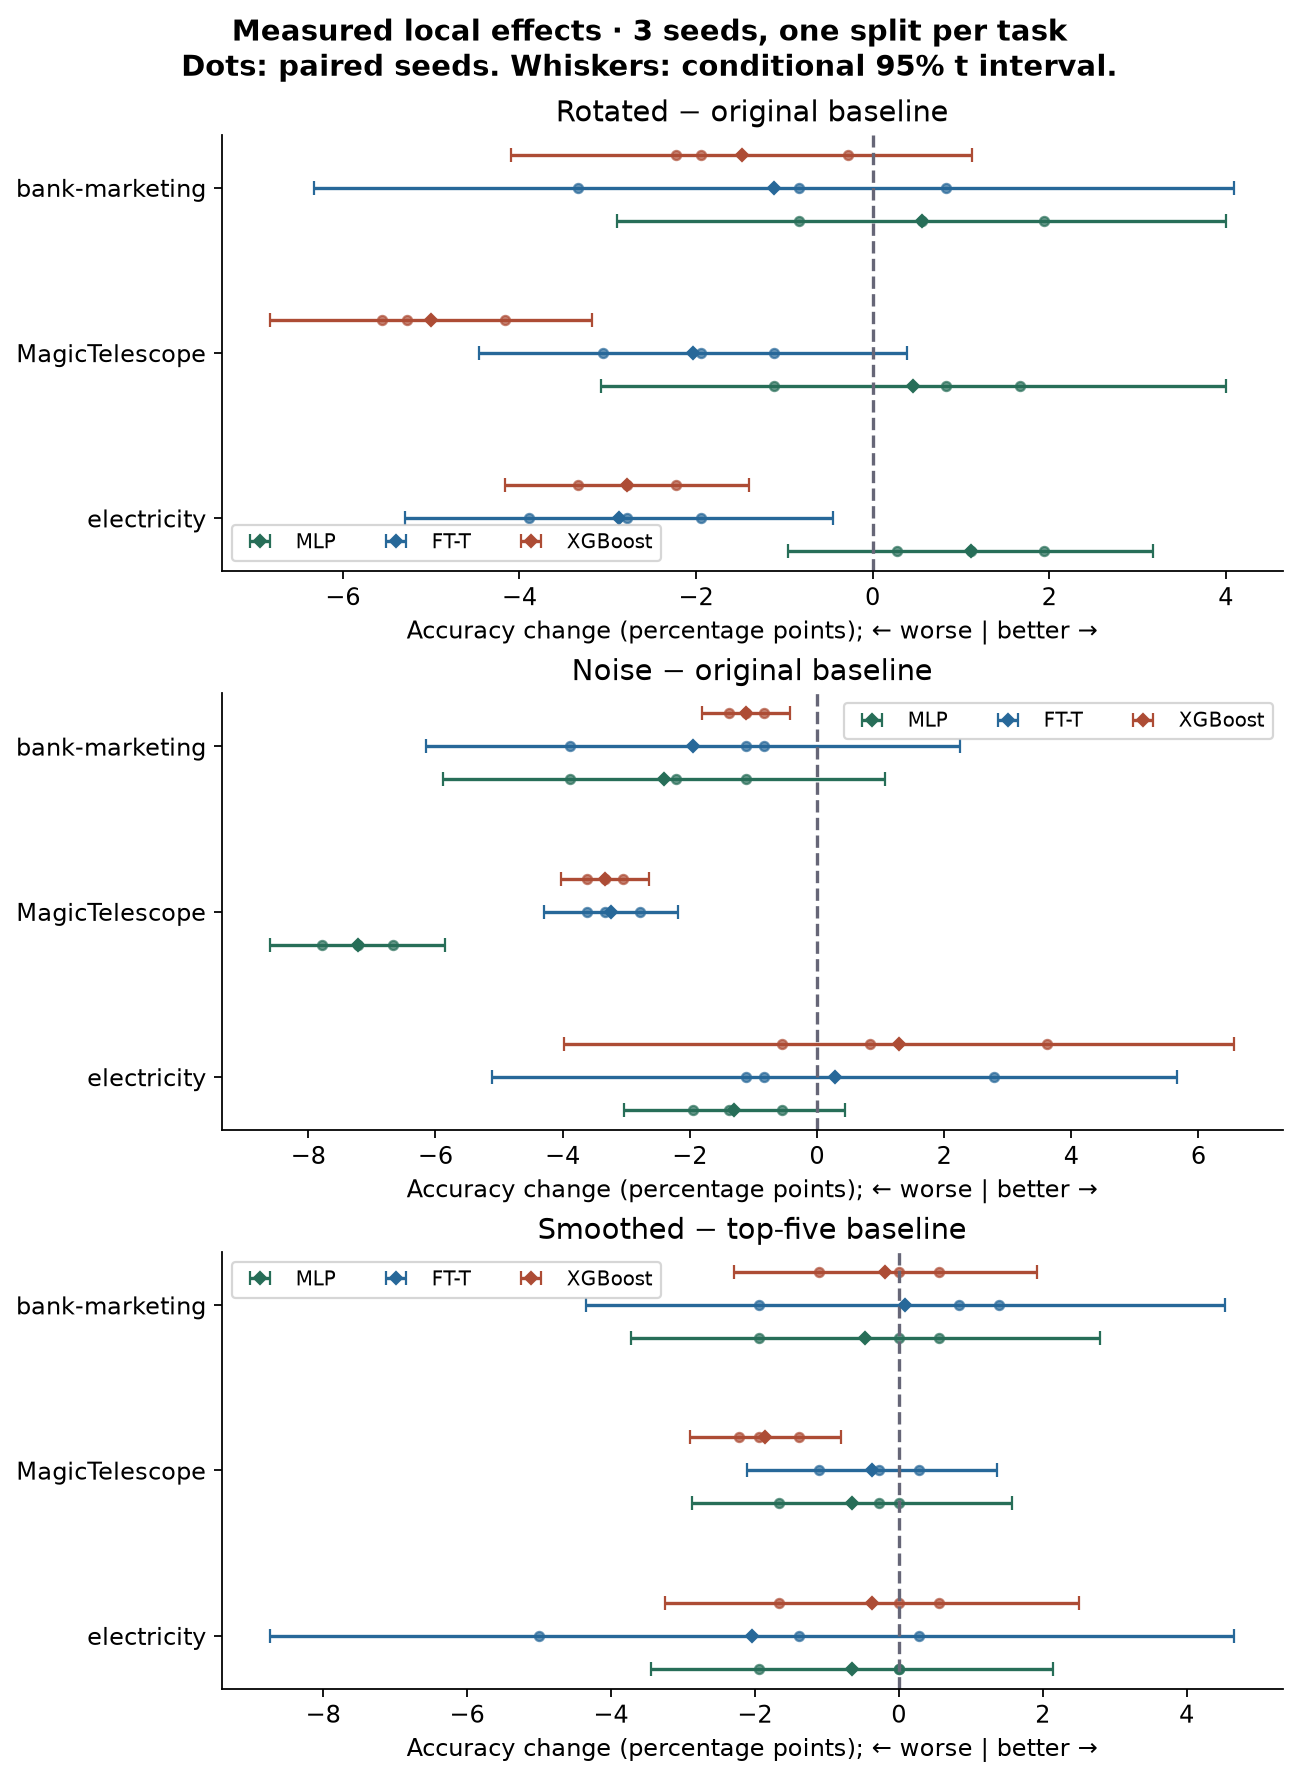

Author-reference local effects: per-seed differences and conditional 95% t intervals on a shared test set.

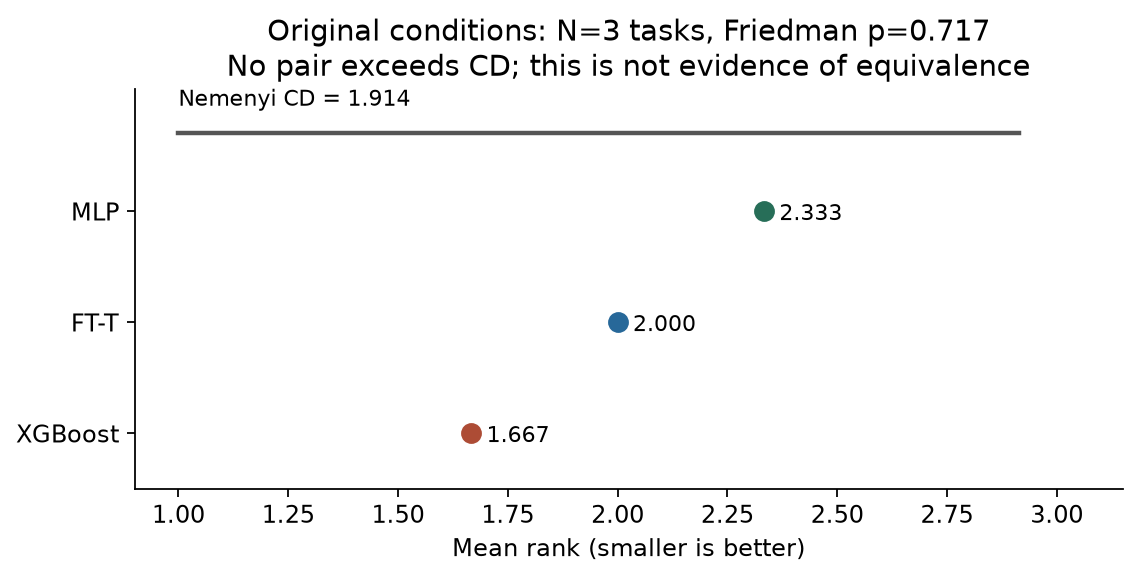

Author-reference original-condition ranks: three tasks; no Nemenyi pair exceeds CD. Nonsignificance does not establish equivalence.

In [ ]:
# CHECK — recompute accuracy from predictions; verify the paired baseline.
for dataset,row in result['datasets'].items():
    for condition,runs in row['runs'].items():
        for model,rr in runs.items():
            for run in rr:
                assert np.isclose(run['accuracy'],accuracy_score(row['test_y'],np.array(run['probability'])>=.5))
    for model in MODELS:
        fresh=paired_effect([a['accuracy'] for a in row['runs']['smoothed'][model]],[a['accuracy'] for a in row['runs']['top5'][model]])
        assert np.isclose(fresh['mean'],row['effects']['smoothed'][model]['mean'])
print('CHECK: saved prediction arithmetic and smoothing baseline pass.')

## EXIT · Your interpretation is the deliverable
Complete in your own words, then paste this text and the printed report to the teacher:

1. **Smoothness:** changed labels / training rows; paired effect for one model; why evaluation labels stay raw.
2. **Rotation:** explain X′Rᵀ=X and W′=WR; why Adam training can still change the score.
3. **Noise:** report one exception or uncertainty; explain population independence versus accidental sample patterns.
4. **Claim limit:** identify the experimental unit, the correct smoothing baseline, and two missing paper-protocol components.
5. **Mission:** one control you will require before treating a future relational-model gain as evidence for the thesis.

YOUR ANSWER: ...

In [ ]:
# PROVIDED — stable executable identity; excludes interpreter reference bookkeeping
def code_fingerprint(function):
    """Hash bytecode and semantic constants, names, defaults and signature fields.

    marshal.dumps(code) can change its reference flags after a function executes.
    File/line locations and interpreter bookkeeping are intentionally excluded.
    The operator separately hashes data, settings, versions and model methods.
    """
    def encode(value):
        if isinstance(value,types.CodeType):
            return dict(bytecode=value.co_code.hex(),constants=[encode(x) for x in value.co_consts],
                names=value.co_names,varnames=value.co_varnames,freevars=value.co_freevars,
                cellvars=value.co_cellvars,flags=value.co_flags,argcount=value.co_argcount,
                posonly=value.co_posonlyargcount,kwonly=value.co_kwonlyargcount,
                exceptiontable=value.co_exceptiontable.hex())
        if isinstance(value,(tuple,list)):return [encode(x) for x in value]
        if isinstance(value,dict):return {str(k):encode(v) for k,v in sorted(value.items())}
        if isinstance(value,bytes):return {'bytes':value.hex()}
        if value is None or isinstance(value,(str,int,float,bool)):return value
        return {'type':type(value).__name__,'repr':repr(value)}
    payload=dict(code=encode(function.__code__),defaults=encode(function.__defaults__),kwdefaults=encode(function.__kwdefaults__))
    return hashlib.sha256(json.dumps(payload,sort_keys=True,separators=(',',':')).encode()).hexdigest()

In [ ]:
# EXIT TICKET — implementation identity and actual measured effects.
tracked=['smooth_targets','rotate_splits','add_noise_features','paired_effect','fit_arm','prepare_task','run_experiment','rank_summary','reglu']
live_identity={n:code_fingerprint(globals()[n]) for n in tracked}
for cls in [CheckpointMLP,CheckpointFT,CheckpointAttention,CheckpointBlock]:
    for method in ['__init__','forward']:
        live_identity[cls.__name__+'.'+method]=code_fingerprint(getattr(cls,method))
ticket=dict(lesson=51,protocol=result['protocol'],verdict='INCOMPARABLE',identity=live_identity,
            effects={n:r['effects'] for n,r in result['datasets'].items()},statistics=result['statistics'])
(LABS/'data/cache/l051-exit.json').write_text(json.dumps(ticket,indent=2))
(LABS/'data/cache/l051-teacher-results.json').write_text(json.dumps(result,indent=2))
print(json.dumps(ticket,indent=2))

## 8. Required next step: increase evidence, preserve the verdict




The `closer` preset expands each released task to 6,000 rows, 50 neural epochs and 400 tree rounds, retaining three model seeds and all five conditions. The `paper` resource preset uses up to 20,000 rows, 100 epochs, 1,000 trees and five seeds. Its name denotes scale: it still lacks the original suite, model roster, search distributions, repeated search orders and aggregation. Neither preset is an exact paper reproduction.




**Larger attempt completed:** 2471 seconds for the CPU experiment over all three tasks and five conditions. Original-condition accuracy means ± sample SD over three seeds — electricity: MLP 0.8003 ± 0.0038, FT-T 0.8192 ± 0.0065, XGBoost 0.8539 ± 0.0032; MagicTelescope: MLP 0.8506 ± 0.0038, FT-T 0.8481 ± 0.0043, XGBoost 0.8578 ± 0.0013; bank-marketing: MLP 0.7883 ± 0.0025, FT-T 0.8047 ± 0.0049, XGBoost 0.8139 ± 0.0013. **INCOMPARABLE** to the paper; the full resource preset and original search curves remain NOT_RUN. [Full scale-up evidence, paired effects and ledger](_paper_repro_l051_closer_summary.json). The timing includes heavy workspace CPU contention and is not a model-speed comparison.




Local command: `python labs/_paper_repro_l051.py --preset closer --out labs/data/cache/l051-your-run`. For T4 compute: `modal run --detach modal/l051_paper_repro.py --preset closer`, or enable the notebook’s gated cell. Both use the same visible implementation. Resume occurs at completed-dataset boundaries; a partly completed dataset restarts. Source, data, configuration and environment changes require a new output directory.




Missing suite coverage includes credit, covertype, pol, house_16H, MiniBooNE, Higgs, eye_movements, Diabetes130US, jannis, default-of-credit-card-clients, Bioresponse, california and heloc. The smoothing-lengthscale curves, feature-removal sweep and full search-reordering experiment remain unrun. Electricity is evaluated under this benchmark’s IID partition, not a deployment-time forecast.




[Reproduction contract and source audit](l051-reproduction.md) · [Local evidence](_verify_l051_results.json) · [Modal operator](../modal/l051_paper_repro.py)

### Required larger attempt · explicit gate
The same experiment is inlined above. This operator checkpoints completed datasets, validates the implementation/data/configuration/environment identity and prints an honest conclusion ledger. Attach a GPU for a larger run, set `RUN_PAPER_REPRO=True`, and use a fresh output directory after editing code. The `paper` preset means a larger local resource budget, not source-protocol equivalence. Completing this cell cannot by itself reproduce the missing search curves.

The gate re-hashes the current notebook code when run, rather than relying on the earlier EXIT hash.

In [ ]:
# PROVIDED — visible resume/operator contract
def reproduce(preset='closer',out='labs/data/cache/l051-closer',device='cpu',runner=None,identity=None):
    runner=run_experiment if runner is None else runner
    root=Path(__file__).parent;cache=root/'data/cache/l051'
    if identity is None:
        identity={f:hashlib.sha256((root/f).read_bytes()).hexdigest() for f in ['relkit/bias_interventions.py','relkit/checkpoint.py','_paper_repro_l051.py']}
    dataset_hashes={n:load_task(n,cache)[2]['sha256'] for n in DATASETS}
    import importlib.metadata
    versions={p:importlib.metadata.version(p) for p in ['numpy','scipy','scikit-learn','torch','xgboost']}
    contract=dict(preset=preset,config=PRESETS[preset],identity=identity,data=dataset_hashes,device=device,versions=versions,python=sys.version,platform=platform.machine())
    out=Path(out);out.mkdir(parents=True,exist_ok=True);path=out/'contract.json'
    if path.exists() and json.loads(path.read_text())!=contract:raise ValueError('Changed implementation/data/config/environment: use a new output directory')
    path.write_text(json.dumps(contract,indent=2));combined=None
    with threadpool_limits(limits=1):
        for name in DATASETS:
            file=out/f'{name}.json'
            if file.exists():
                current=json.loads(file.read_text());print('RESUME',name,flush=True)
            else:
                current=runner(preset,names=[name],cache=cache,device=device)
                temp=file.with_suffix('.tmp');temp.write_text(json.dumps(current,indent=2));temp.replace(file)
            if combined is None:combined={**current,'datasets':{},'elapsed_s':0.}
            combined['datasets'].update(current['datasets']);combined['elapsed_s']+=current['elapsed_s']
    combined['statistics']={c:rank_summary(combined['datasets'],c) for c in ['original','rotated','noise','top5','smoothed']}
    combined['contract']=contract
    combined['ledger']={'verified_here':'Source transformation parity and declared local measurements',
      'paper_claim':'CITED, NOT_REPRODUCED: published aggregated sensitivity and tuning curves',
      'scale_up':f'{preset}: INCOMPARABLE; local split/recipe, 2023 release, 3-task subset, no published search reorders'}
    (out/'summary.json').write_text(json.dumps(combined,indent=2));print(combined['ledger']);return combined

In [ ]:
# PROVIDED — Colab/local gate. Your current live runner is passed explicitly.
RUN_PAPER_REPRO=False
PAPER_PRESET='closer'
if RUN_PAPER_REPRO:
    live_identity={n:code_fingerprint(globals()[n]) for n in tracked+['load_task','reproduce','code_fingerprint']}
    for cls in [CheckpointMLP,CheckpointFT,CheckpointAttention,CheckpointBlock]:
        for method in ['__init__','forward']:
            live_identity[cls.__name__+'.'+method]=code_fingerprint(getattr(cls,method))
    live_identity['settings']=dict(DATASETS=DATASETS,PRESETS=PRESETS,CONDITIONS=CONDITIONS,MODELS=MODELS)
    # The inlined operator resolves its root from this temporary file identity.
    previous_file=__file__;__file__=str(LABS/'_paper_repro_l051.py')
    try:
        larger=reproduce(PAPER_PRESET,out=LABS/'data/cache/l051-student-closer',
            device='cuda' if torch.cuda.is_available() else 'cpu',runner=run_experiment,identity=live_identity)
    finally:__file__=previous_file
else:print('Scale-up gate OFF. Paper search curves remain NOT_RUN; author closer evidence is separately labeled.')